### Handout K Nearest Neighbor Classifier und Train-Test-Split

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

Für den Train-Test-Split werden in sklearn Funktionen bereitgestellt. Wichtig ist hierbei auf die Daten zu achten, oft kann es sein, dass ein einfacher, zufälliger Split nicht die beste Wahl ist.

Mit der Funktion `train_test_split` können die Daten zufällig aufgetrennt werden. Dabei kann man den Anteil der Testdaten angeben, im unteren Beispiel 20% aller Daten. 

Der `random_state` bewirkt, dass Ergebnisse reproduzierbar sind - Achtung, wenn Sie mehrere Splits haben möchten, dann müssen Sie unterschiedliche Seeds verwenden.

Dem Parameter `stratify` wird ein Vektor übergeben - es wird dann darauf geachtet, dass der Anteil der darin enthaltenen Ausprägungen/Label in Train- und Testdaten gleich ist.

In [2]:
X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Beim KNN handelt es sich um ein distanzbasiertes Verfahren, d.h. Distanzen sind wichtig, und entsprechend sollten die Daten auf einheitliche Wertebereiche gebracht werden.

Damit keine Informationen von den Testdaten schon in die Trainingsdaten einfließen, werden die Daten anhand der Kenngrößen der Trainingsdaten normalisiert.

In [3]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In Python sklearn ist der KNN Classifier in der Funktion KNeighborsClassifier realisiert. Hier kann mit dem Parameter `n_neighbors` der Parameter $K$ eingegeben werden. Standardmäßig wird die Minkowski-Distanz verwendet, dabei erhält man durch `p=2` die euklidische Distanz.
Da der Algorithmus distanzbasiert arbeitet, ist es wichtig, dass die Daten in einem einheitlichen Wertebereich vorliegen. 

In [4]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)

train_prediction = knn.predict(X_train)
test_prediction = knn.predict(X_test)

print("Train: "+ str(accuracy_score(y_train, train_prediction)))

print("Test: "+ str(accuracy_score(y_test, test_prediction)))

Train: 0.9583333333333334
Test: 0.9666666666666667


Die _Decision Surfaces_ können z.B. mit der unteren Funktion dargestellt werden. Wenn man den Parameter $K$ ändert, dann kann man schön die Flexibilität des Modells betrachten

In [5]:
# Quelle: https://data-science-crashkurs.de/chapters/kapitel_07.html

def plot_decision_surface(model, X, Y, ax=None, title=None):
    h = .01 # step size in the mesh
    x_min, x_max = X.iloc[:,0].min() - .5, X.iloc[:,0].max() + .5
    y_min, y_max = X.iloc[:,1].min() - .5, X.iloc[:,1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    model.fit(X.values, Y)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    if ax is None:
        plt.figure()
        ax = plt.gca()
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.pcolormesh(xx, yy, Z, alpha=0.4, shading='auto')
    ax.scatter(X.iloc[:,0], X.iloc[:,1],c=Y, marker='.')
    
    ax.set_xlabel(X.columns[0])
    ax.set_ylabel(X.columns[1])
    if title is None:
        title = str(model)
    ax.set_title(title)
    


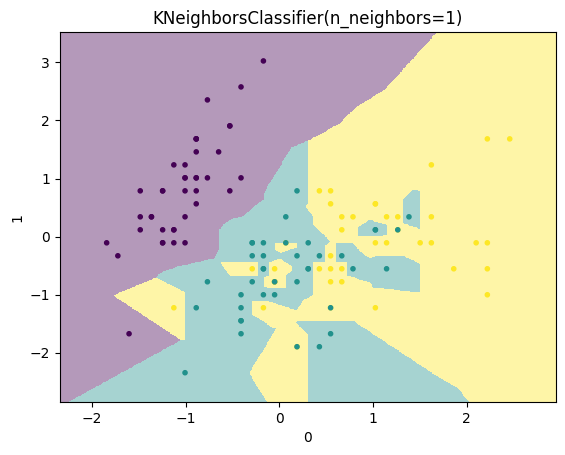

In [6]:
plot_decision_surface(KNeighborsClassifier(n_neighbors=1),pd.DataFrame(X_train[:,:2]), y_train)